# LGBM 예측 모델 — final_aic_features 고정

OLS 예측 노트북(`Modeling_OLS2_revised.ipynb`)에서 확정한 `final_aic_features`를 그대로 사용하여 LGBMRegressor를 학습하고, Optuna로 하이퍼파라미터를 튜닝하여 OLS와 비교 가능한 결과를 산출한다.

- 변수 선택은 하지 않는다 (OLS와 동일 변수)
- train/test split은 `final_features.json`의 `split_date` 기준 강제
- Optuna 튜닝은 train 내부 TimeSeriesSplit CV에서만 수행 (test 누수 금지)


In [1]:
# =========================
# 0. 기본 설정
# =========================
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

import optuna
from optuna.trial import TrialState

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
DATA_FILE_NAME = "dataset4_derived_full_with_dummies.csv"
CONFIG_PATH = Path("../outputs/baseline/final_features.json")
OUT_DIR = Path("../outputs/baseline")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. 설정 로드 & 데이터 준비

In [2]:
# =========================
# 1-1. final_features.json 로드
# =========================
if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"{CONFIG_PATH} 가 없습니다. 먼저 Modeling_OLS2_revised.ipynb의 §14를 실행하세요."
    )

cfg = json.load(open(CONFIG_PATH, encoding="utf-8"))
TARGET = cfg["target"]
SPLIT_DATE = pd.Timestamp(cfg["split_date"])
TEST_SIZE = cfg.get("test_size")
final_aic_features = list(cfg["final_aic_features"])

print("TARGET        :", TARGET)
print("SPLIT_DATE    :", SPLIT_DATE.date())
print("TEST_SIZE(cfg):", TEST_SIZE)
print("n_features    :", len(final_aic_features))
print("features      :", final_aic_features)


TARGET        : oil_diff_target
SPLIT_DATE    : 2022-05-06
TEST_SIZE(cfg): 0.2
n_features    : 19
features      : ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'oil_diff_lag1', 'oil_volatility_20', 'MA_ratio', 'MA_5_gt_MA_20', 'is_friday', 'gfc_2008_shock', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'war_2022_shock', 'war_2022_window', 'cond_opec_cut']


In [3]:
# =========================
# 1-2. 데이터 로드
# =========================
def find_data_path(filename=DATA_FILE_NAME):
    cwd = Path.cwd().resolve()
    candidates = []
    for base in [cwd, *cwd.parents]:
        candidates.extend([
            base / "data" / "Finance_Final" / filename,
            base.parent / "data" / "Finance_Final" / filename,
            base / "Finance_Final" / filename,
            base / filename,
        ])
    for p in candidates:
        if p.exists():
            return p
    for base in [cwd, *cwd.parents]:
        matches = [p for p in base.rglob(filename) if ".git" not in p.parts]
        if matches:
            return matches[0]
    raise FileNotFoundError(filename)

DATA_PATH = find_data_path()
print("DATA_PATH:", DATA_PATH)

cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
DATE_COL = next((c for c in ["date", "Date", "DATE"] if c in cols), cols[0])

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.rename(columns={DATE_COL: "date"}).set_index("date").sort_index()

df_model = df.dropna().copy()
print("원본:", df.shape, "→ 결측 제거:", df_model.shape)
print("기간:", df_model.index.min().date(), "~", df_model.index.max().date())

missing_feats = [f for f in final_aic_features if f not in df_model.columns]
if missing_feats:
    raise KeyError(f"데이터에 없는 feature: {missing_feats}")


DATA_PATH: /Users/jeondonghyeon/Documents/05_BAF/BAF-26-1-finance_2/data/Finance_Final/dataset4_derived_full_with_dummies.csv
원본: (4799, 43) → 결측 제거: (4798, 43)
기간: 2007-02-01 ~ 2026-03-13


In [4]:
# =========================
# 1-3. SPLIT_DATE 기준 train/test 분리
# =========================
df_train = df_model.loc[df_model.index <  SPLIT_DATE].copy()
df_test  = df_model.loc[df_model.index >= SPLIT_DATE].copy()

print("train:", df_train.index.min().date(), "~", df_train.index.max().date(), "| n =", len(df_train))
print("test :", df_test.index.min().date(),  "~", df_test.index.max().date(),  "| n =", len(df_test))

X_train = df_train[final_aic_features].copy()
y_train = df_train[TARGET].copy()
X_test  = df_test[final_aic_features].copy()
y_test  = df_test[TARGET].copy()

print("\nX_train:", X_train.shape, " | X_test:", X_test.shape)


train: 2007-02-01 ~ 2022-05-05 | n = 3838
test : 2022-05-06 ~ 2026-03-13 | n = 960

X_train: (3838, 19)  | X_test: (960, 19)


## 2. 평가 유틸

In [5]:
# =========================
# 2. 평가 함수
# =========================
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_pred != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "RMSE": rmse,
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
        "DirAcc": directional_accuracy(y_true, y_pred),
    }

def model_row(name, y_true, y_pred, n_vars):
    m = regression_metrics(y_true, y_pred)
    return {"model": name, "n_vars": n_vars, **m}


## 3. 기준선 — naive & OLS(AIC)

In [6]:
# =========================
# 3-1. naive 기준선
# =========================
pred_naive_zero = np.zeros(len(y_test))
pred_naive_lag1 = df_model[TARGET].shift(1).loc[y_test.index].fillna(0).values

naive_zero_row = model_row("naive_zero", y_test, pred_naive_zero, n_vars=0)
naive_lag1_row = model_row("naive_lag1", y_test, pred_naive_lag1, n_vars=1)
print("naive_zero:", {k: round(v, 5) if isinstance(v, float) and not np.isnan(v) else v for k, v in naive_zero_row.items() if k != 'model'})
print("naive_lag1:", {k: round(v, 5) for k, v in naive_lag1_row.items() if k != 'model'})


naive_zero: {'n_vars': 0, 'RMSE': 1.81592, 'MAE': 1.32455, 'R2': -9e-05, 'DirAcc': nan}
naive_lag1: {'n_vars': 1, 'RMSE': 2.50734, 'MAE': 1.87925, 'R2': -0.90666, 'DirAcc': 0.5}


In [7]:
# =========================
# 3-2. OLS(AIC) 재계산 (final_aic_features 그대로)
# =========================
X_ols_train = sm.add_constant(X_train, has_constant="add")
X_ols_test  = sm.add_constant(X_test,  has_constant="add")

ols_aic = sm.OLS(y_train, X_ols_train).fit()
pred_ols = ols_aic.predict(X_ols_test).values

ols_row = model_row("OLS (AIC)", y_test, pred_ols, n_vars=len(final_aic_features))
print({k: round(v, 5) if isinstance(v, float) else v for k, v in ols_row.items()})


{'model': 'OLS (AIC)', 'n_vars': 19, 'RMSE': 1.88342, 'MAE': 1.36926, 'R2': -0.07582, 'DirAcc': 0.50104}


## 4. 기본 LGBM (튜닝 전 baseline)

In [8]:
# =========================
# 4. LGBM default
# =========================
lgbm_default = LGBMRegressor(random_state=RANDOM_SEED, verbosity=-1)
lgbm_default.fit(X_train, y_train)
pred_lgbm_default = lgbm_default.predict(X_test)

lgbm_default_row = model_row("LGBM (default)", y_test, pred_lgbm_default, n_vars=len(final_aic_features))
print({k: round(v, 5) if isinstance(v, float) else v for k, v in lgbm_default_row.items()})


{'model': 'LGBM (default)', 'n_vars': 19, 'RMSE': 1.87456, 'MAE': 1.38187, 'R2': -0.06572, 'DirAcc': 0.50625}


## 5. Optuna 하이퍼파라미터 튜닝

- train 내부 `TimeSeriesSplit(n_splits=5)` 의 fold별 RMSE 평균을 최소화
- 각 fold 내부에서 early_stopping(50) — validation fold는 train의 미래 구간이지만 **test는 사용하지 않음**
- TPESampler(seed=42), n_trials=50


In [9]:
# =========================
# 5-1. Optuna objective
# =========================
N_TRIALS = 50
N_SPLITS = 5
EARLY_STOPPING_ROUNDS = 50

def make_params(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.0, 1.0),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

def objective(trial):
    params = make_params(trial)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rmses = []

    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = LGBMRegressor(
            **params,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                       log_evaluation(0)],
        )
        pred = model.predict(X_va)
        rmses.append(float(np.sqrt(mean_squared_error(y_va, pred))))

    return float(np.mean(rmses))


In [10]:
# =========================
# 5-2. Optuna 실행
# =========================
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best_params = study.best_params
best_cv_rmse = study.best_value

print("Best CV RMSE:", round(best_cv_rmse, 6))
print("Best params :")
for k, v in best_params.items():
    print(f"  {k}: {v}")


Best CV RMSE: 1.774734
Best params :
  n_estimators: 232
  learning_rate: 0.03487776753903612
  num_leaves: 127
  max_depth: 11
  min_child_samples: 5
  reg_alpha: 0.8246362282489827
  reg_lambda: 0.798283289712431
  subsample: 0.8238463572387135
  colsample_bytree: 0.8813769806450324


## 6. 최적 파라미터로 최종 학습

In [11]:
# =========================
# 6. best_params로 train 전체 재학습
# =========================
lgbm_tuned = LGBMRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    verbosity=-1,
)
lgbm_tuned.fit(X_train, y_train)
pred_lgbm_tuned = lgbm_tuned.predict(X_test)

lgbm_tuned_row = model_row("LGBM (tuned)", y_test, pred_lgbm_tuned, n_vars=len(final_aic_features))
print({k: round(v, 5) if isinstance(v, float) else v for k, v in lgbm_tuned_row.items()})


{'model': 'LGBM (tuned)', 'n_vars': 19, 'RMSE': 1.91202, 'MAE': 1.39202, 'R2': -0.10875, 'DirAcc': 0.51042}


## 7. 모델 비교 표

In [12]:
# =========================
# 7. 비교 표
# =========================
compare = pd.DataFrame([
    naive_zero_row,
    naive_lag1_row,
    ols_row,
    lgbm_default_row,
    lgbm_tuned_row,
])

naive_lag1_rmse = naive_lag1_row["RMSE"]
compare["vs_naive_lag1"] = (naive_lag1_rmse - compare["RMSE"]) / naive_lag1_rmse

display(compare.round(5).sort_values("RMSE").reset_index(drop=True))
print("vs_naive_lag1 > 0 이면 naive_lag1보다 RMSE가 낮다는 뜻.")


,model,n_vars,RMSE,MAE,R2,DirAcc,vs_naive_lag1
0,naive_zero,0,1.81592,1.32455,-0.00009,NaN,0.27576
1,LGBM (default),19,1.87456,1.38187,-0.06572,0.50625,0.25237
2,OLS (AIC),19,1.88342,1.36926,-0.07582,0.50104,0.24884
3,LGBM (tuned),19,1.91202,1.39202,-0.10875,0.51042,0.23743
4,naive_lag1,1,2.50734,1.87925,-0.90666,0.50000,0.00000


vs_naive_lag1 > 0 이면 naive_lag1보다 RMSE가 낮다는 뜻.


## 8. TimeSeriesSplit CV — 안정성 확인

In [13]:
# =========================
# 8. best_params로 train 내부 TSCV
# =========================
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_rows = []

for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    m = LGBMRegressor(**best_params, random_state=RANDOM_SEED, verbosity=-1)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                   log_evaluation(0)],
    )
    pred = m.predict(X_va)
    metrics = regression_metrics(y_va, pred)
    cv_rows.append({
        "fold": fold_idx,
        "valid_start": X_va.index.min().date(),
        "valid_end":   X_va.index.max().date(),
        "n_valid": len(X_va),
        **metrics,
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(5))

summary = cv_df[["RMSE", "MAE", "R2", "DirAcc"]].agg(["mean", "std"]).T
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.5f} ± {r['std']:.5f}", axis=1)
print("\n===== fold 평균 ± 표준편차 =====")
display(summary[["mean ± std"]])

single_test = {k: lgbm_tuned_row[k] for k in ["RMSE", "MAE", "R2", "DirAcc"]}
consistency = pd.DataFrame({
    "CV_mean": cv_df[["RMSE", "MAE", "R2", "DirAcc"]].mean(),
    "CV_std":  cv_df[["RMSE", "MAE", "R2", "DirAcc"]].std(),
    "single_split_test": pd.Series(single_test),
})
consistency["abs_gap"]    = (consistency["single_split_test"] - consistency["CV_mean"]).abs()
consistency["within_1std"] = consistency["abs_gap"] <= consistency["CV_std"]
print("\n===== CV vs Single-split test =====")
display(consistency.round(5))


,fold,valid_start,valid_end,n_valid,RMSE,MAE,R2,DirAcc
0,1,2009-08-20,2012-03-02,639,1.66622,1.26840,0.02383,0.53365
1,2,2012-03-05,2014-09-15,639,1.28847,0.96067,-0.00329,0.52895
2,3,2014-09-16,2017-03-29,639,1.32519,1.01350,-0.00448,0.45696
3,4,2017-03-30,2019-10-17,639,1.15017,0.81647,0.00152,0.50391
4,5,2019-10-18,2022-05-05,639,3.44361,1.42906,0.00558,0.52582



===== fold 평균 ± 표준편차 =====


,mean ± std
RMSE,1.77473 ± 0.95204
MAE,1.09762 ± 0.24693
R2,0.00463 ± 0.01146
DirAcc,0.50986 ± 0.03170



===== CV vs Single-split test =====


,CV_mean,CV_std,single_split_test,abs_gap,within_1std
RMSE,1.77473,0.95204,1.91202,0.13729,True
MAE,1.09762,0.24693,1.39202,0.29441,False
R2,0.00463,0.01146,-0.10875,0.11338,False
DirAcc,0.50986,0.03170,0.51042,0.00056,True


## 9. 예측 시각화

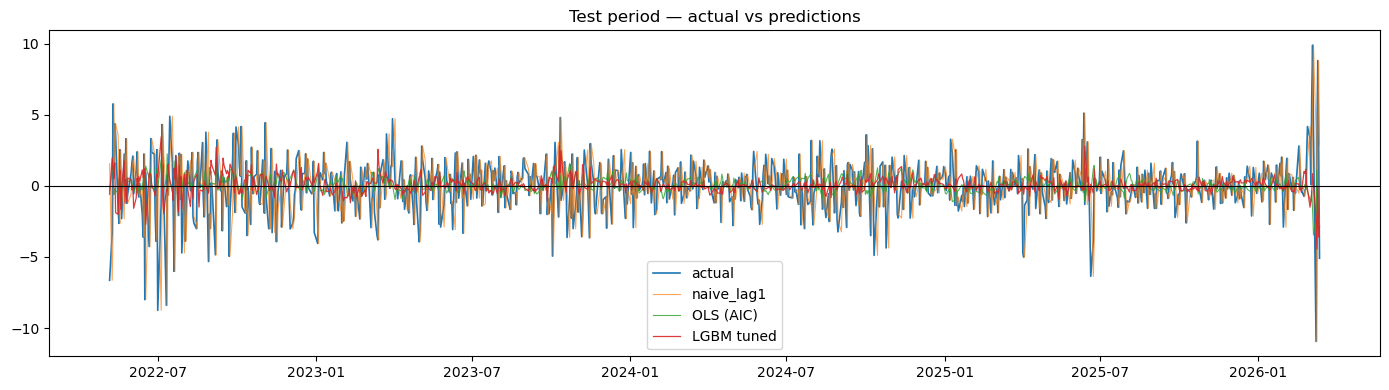

In [14]:
# =========================
# 9-1. test 구간 actual vs 예측
# =========================
plot_df = pd.DataFrame({
    "actual":      y_test.values,
    "naive_lag1":  pred_naive_lag1,
    "OLS (AIC)":   pred_ols,
    "LGBM tuned":  pred_lgbm_tuned,
}, index=y_test.index)

plt.figure(figsize=(14, 4))
plt.plot(plot_df.index, plot_df["actual"], label="actual", lw=1.2)
plt.plot(plot_df.index, plot_df["naive_lag1"], label="naive_lag1", lw=0.8, alpha=0.7)
plt.plot(plot_df.index, plot_df["OLS (AIC)"],  label="OLS (AIC)",  lw=0.8, alpha=0.8)
plt.plot(plot_df.index, plot_df["LGBM tuned"], label="LGBM tuned", lw=0.9, alpha=0.9)
plt.axhline(0, lw=0.8, color="black")
plt.title("Test period — actual vs predictions")
plt.legend()
plt.tight_layout()
plt.show()


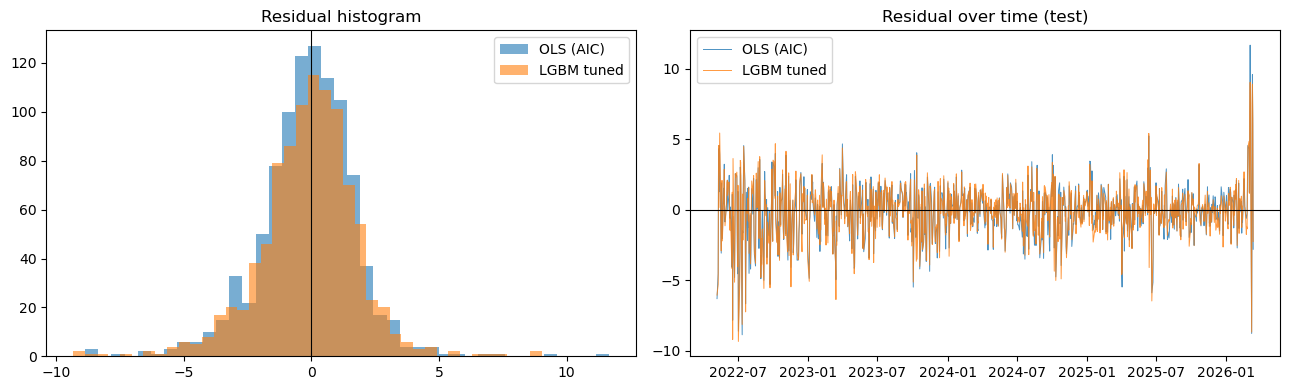

OLS  잔차 std: 1.8797
LGBM 잔차 std: 1.90925


In [15]:
# =========================
# 9-2. 잔차 분포 비교 (OLS vs LGBM)
# =========================
resid_ols  = y_test.values - pred_ols
resid_lgbm = y_test.values - pred_lgbm_tuned

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(resid_ols,  bins=40, alpha=0.6, label="OLS (AIC)")
axes[0].hist(resid_lgbm, bins=40, alpha=0.6, label="LGBM tuned")
axes[0].axvline(0, lw=0.8, color="black")
axes[0].set_title("Residual histogram")
axes[0].legend()

axes[1].plot(y_test.index, resid_ols,  lw=0.7, alpha=0.8, label="OLS (AIC)")
axes[1].plot(y_test.index, resid_lgbm, lw=0.7, alpha=0.8, label="LGBM tuned")
axes[1].axhline(0, lw=0.8, color="black")
axes[1].set_title("Residual over time (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("OLS  잔차 std:", round(float(np.std(resid_ols)),  5))
print("LGBM 잔차 std:", round(float(np.std(resid_lgbm)), 5))


## 10. 결과 저장

In [ ]:
# =========================
# 10. 저장
# =========================
# 10-1. best_params
best_params_payload = {
    "random_state": RANDOM_SEED,
    "n_trials": N_TRIALS,
    "n_splits_cv": N_SPLITS,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "best_cv_rmse": best_cv_rmse,
    "best_params": best_params,
    "split_date": str(SPLIT_DATE.date()),
    "target": TARGET,
    "n_features": len(final_aic_features),
}
with open(OUT_DIR / "lgbm_best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_params_payload, f, ensure_ascii=False, indent=2)

# 10-2. 비교 표
compare.to_csv(OUT_DIR / "lgbm_prediction_compare.csv", index=False)

# 10-3. CV fold 결과
cv_df.to_csv(OUT_DIR / "lgbm_cv_results.csv", index=False)

# 10-4. test 예측값
pred_test_df = pd.DataFrame({
    "date":        y_test.index,
    "actual":      y_test.values,
    "naive_lag1":  pred_naive_lag1,
    "ols_aic":     pred_ols,
    "lgbm_default": pred_lgbm_default,
    "lgbm_tuned":  pred_lgbm_tuned,
})
pred_test_df.to_csv(OUT_DIR / "lgbm_pred_test.csv", index=False)

print("저장 완료:")
for fname in ["lgbm_best_params.json", "lgbm_prediction_compare.csv",
            "lgbm_cv_results.csv", "lgbm_pred_test.csv"]:
    print(" -", OUT_DIR / fname)


저장 완료:
 - ../outputs/baseline/lgbm_best_params.json
 - ../outputs/baseline/lgbm_prediction_compare.csv
 - ../outputs/baseline/lgbm_cv_results.csv
 - ../outputs/baseline/lgbm_pred_test.csv
